In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 파생변수 추가 버전 데이터
type2_df = pd.read_csv('../../data/df_type2_파생변수추가.csv')
type2_df.columns = type2_df.columns.str.strip()

NEW_DERIVED = [
    'clamp_per_press', 'temp_diff',
    'press_time_ratio', 'spray_cycle_ratio', 'heat_index'
    
]

print(f"Shape: {type2_df.shape}")
print(f"\n신규 파생변수: {NEW_DERIVED}")
print(f"\n컬럼 수: 원본 25 → 파생변수 추가 {type2_df.shape[1]}")

Shape: (1964, 33)

신규 파생변수: ['clamp_per_press', 'temp_diff', 'press_time_ratio', 'spray_cycle_ratio', 'heat_index']

컬럼 수: 원본 25 → 파생변수 추가 33


In [2]:
type2_df.columns

Index(['id', 'Product_Type', 'Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3',
       'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time',
       'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time',
       'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time',
       'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp',
       'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity',
       'Pressure_Diff_ratio', 'clamp_per_press', 'temp_diff',
       'press_time_ratio', 'spray_cycle_ratio', 'heat_index', 'vel_accel',
       'vel_ratio', 'Defect_Status', 'Defect_Type'],
      dtype='str')

In [3]:
type2_df.head()

,id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,...,Pressure_Diff_ratio,clamp_per_press,temp_diff,press_time_ratio,spray_cycle_ratio,heat_index,vel_accel,vel_ratio,Defect_Status,Defect_Type
0,4207011,2,11,0.156,0.166,0.192,2.723,265,0.012,20,...,2.245283,0.600000,638.4,3.416667,0.341530,19.0568,0.010,1.156627,0,Normal
1,4208012,2,12,0.157,0.166,0.204,2.730,264,0.014,19,...,2.250000,0.604377,638.8,2.857143,0.342466,18.9810,0.009,1.228916,0,Normal
2,4209013,2,13,0.156,0.170,0.204,2.715,265,0.012,18,...,2.245283,0.606723,638.9,3.416667,0.342466,18.9945,0.014,1.200000,0,Normal
3,4210014,2,14,0.154,0.170,0.202,2.717,264,0.011,20,...,2.253788,0.611765,638.9,3.818182,0.342466,18.9945,0.016,1.188235,0,Normal
4,4211015,2,15,0.146,0.160,0.198,2.684,264,0.012,20,...,2.253788,0.600000,638.8,3.500000,0.342466,18.9504,0.014,1.237500,0,Normal


In [4]:
cols = ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity']
type2_df['Velocity_minmax'] = type2_df[cols].max(axis=1) - type2_df[cols].min(axis=1)

In [5]:
display(type2_df[['Velocity_minmax']].head()) 
display(type2_df[['Velocity_minmax']].tail())

,Velocity_minmax
0,2.567
1,2.573
2,2.559
3,2.563
4,2.538


,Velocity_minmax
1959,2.392
1960,2.392
1961,2.342
1962,2.370
1963,2.385


In [6]:
# 파생변수는 CSV에 이미 포함 — 추가 계산 불필요
# 기존 통계 노트북 호환용 변수 정의만 유지
type2_df['Pressure_Diff_ratio'] = type2_df['Casting_Pressure'] / type2_df['Cylinder_Pressure']
print("✅ 데이터 로드 완료 (파생변수 이미 포함)")

✅ 데이터 로드 완료 (파생변수 이미 포함)


In [7]:
type2_df.columns

Index(['id', 'Product_Type', 'Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3',
       'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time',
       'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time',
       'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time',
       'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp',
       'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity',
       'Pressure_Diff_ratio', 'clamp_per_press', 'temp_diff',
       'press_time_ratio', 'spray_cycle_ratio', 'heat_index', 'vel_accel',
       'vel_ratio', 'Defect_Status', 'Defect_Type', 'Velocity_minmax'],
      dtype='str')

In [8]:
type2_df.columns = type2_df.columns.str.strip()

In [9]:
type2_df.describe()

,id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,...,Pressure_Diff_ratio,clamp_per_press,temp_diff,press_time_ratio,spray_cycle_ratio,heat_index,vel_accel,vel_ratio,Defect_Status,Velocity_minmax
count,1.964000e+03,1964.0,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,...,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000
mean,5.662140e+06,2.0,337.792261,0.154493,0.168430,0.202365,2.576213,264.714358,0.011692,17.537678,...,2.249035,0.618744,622.647352,3.201395,0.324716,20.107144,0.013937,1.202199,0.253055,2.421722
std,1.013730e+06,0.0,195.490862,0.004829,0.004079,0.005094,0.085683,0.738559,0.000889,1.529505,...,0.002974,0.017637,9.326271,0.346476,0.019825,1.657583,0.006473,0.042473,0.434873,0.085765
min,4.207011e+06,2.0,0.000000,0.139000,0.158000,0.184000,2.470000,247.000000,0.009000,2.000000,...,2.242424,0.580537,598.700000,2.357143,0.096108,14.796000,-0.002000,1.068966,0.000000,2.310000
25%,4.698255e+06,2.0,169.750000,0.152000,0.165000,0.200000,2.516000,264.000000,0.011000,17.000000,...,2.245283,0.600000,616.000000,2.928571,0.297935,18.846450,0.010000,1.172414,0.000000,2.361750
50%,5.570384e+06,2.0,334.000000,0.156000,0.168000,0.202000,2.528000,265.000000,0.012000,18.000000,...,2.249057,0.622896,622.600000,3.181818,0.335180,20.215000,0.014000,1.201766,0.000000,2.374000
75%,6.551649e+06,2.0,500.250000,0.158000,0.172000,0.206000,2.688250,265.000000,0.012000,19.000000,...,2.250000,0.635906,630.600000,3.416667,0.336111,21.779850,0.018000,1.228916,1.000000,2.533000
max,7.533661e+06,2.0,732.000000,0.162000,0.178000,0.216000,2.744000,266.000000,0.014000,24.000000,...,2.261364,0.654676,647.400000,4.666667,0.355014,22.598600,0.036000,1.350000,1.000000,2.585000


In [10]:
type2_df[['Casting_Pressure','Cylinder_Pressure']].describe()

,Casting_Pressure,Cylinder_Pressure
count,1964.000000,1964.000000
mean,595.350815,264.714358
std,1.507544,0.738559
min,556.000000,247.000000
25%,595.000000,264.000000
50%,595.000000,265.000000
75%,596.000000,265.000000
max,597.000000,266.000000


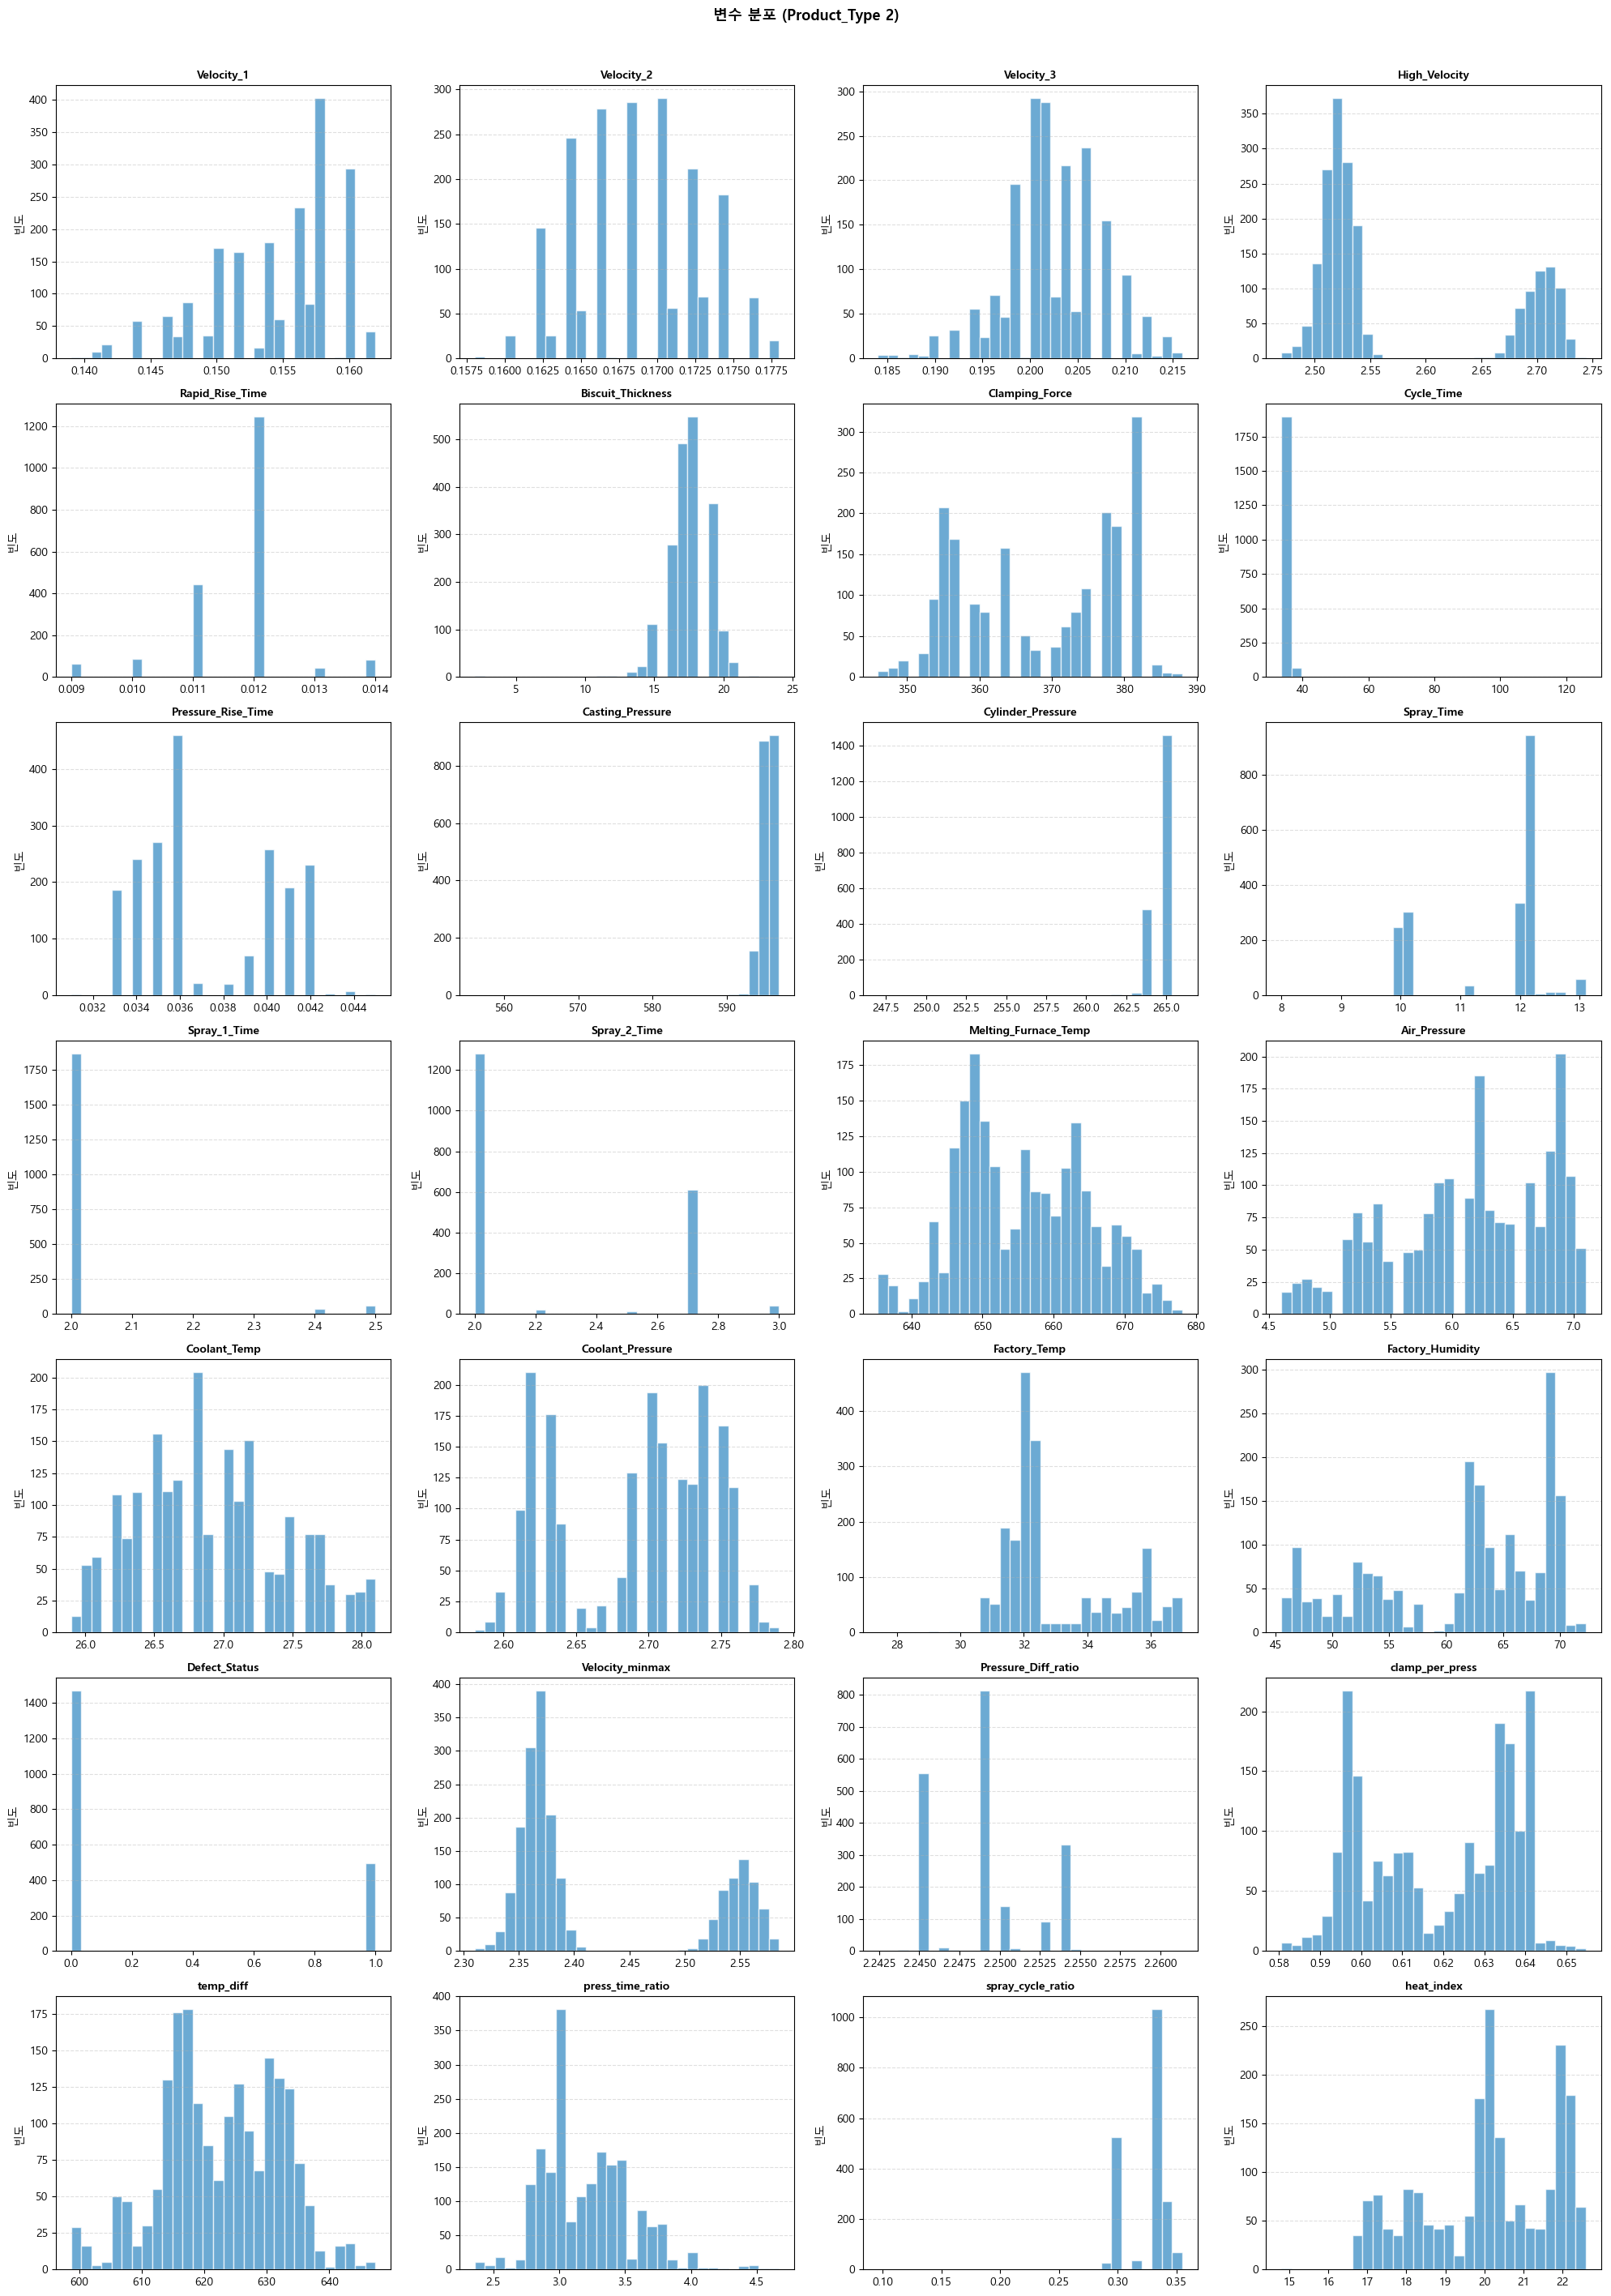

In [11]:
import math

final_vars = [
    'Velocity_1', 
    'Velocity_2', 
    'Velocity_3',
    'High_Velocity', 
    'Rapid_Rise_Time',
    'Biscuit_Thickness', 
    'Clamping_Force', 
    'Cycle_Time',
    'Pressure_Rise_Time', 
    'Casting_Pressure',
    'Cylinder_Pressure', 
    'Spray_Time', 
    'Spray_1_Time',
    'Spray_2_Time', 
    'Melting_Furnace_Temp', 
    'Air_Pressure', 
    'Coolant_Temp',
    'Coolant_Pressure', 
    'Factory_Temp', 
    'Factory_Humidity', 
    'Defect_Status', 
    'Defect_Type', 
    'Velocity_minmax', 
    'Pressure_Diff_ratio',
    'clamp_per_press', 
    'temp_diff',
    'press_time_ratio', 
    'spray_cycle_ratio', 
    'heat_index'
]
# 변수 히스토그램
num_cols = [col for col in final_vars if type2_df[col].dtype in ['int64', 'float64']]

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(type2_df[col].dropna(), bins=30, color='#2E86C1', alpha=0.7, edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('빈도')
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('변수 분포 (Product_Type 2)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

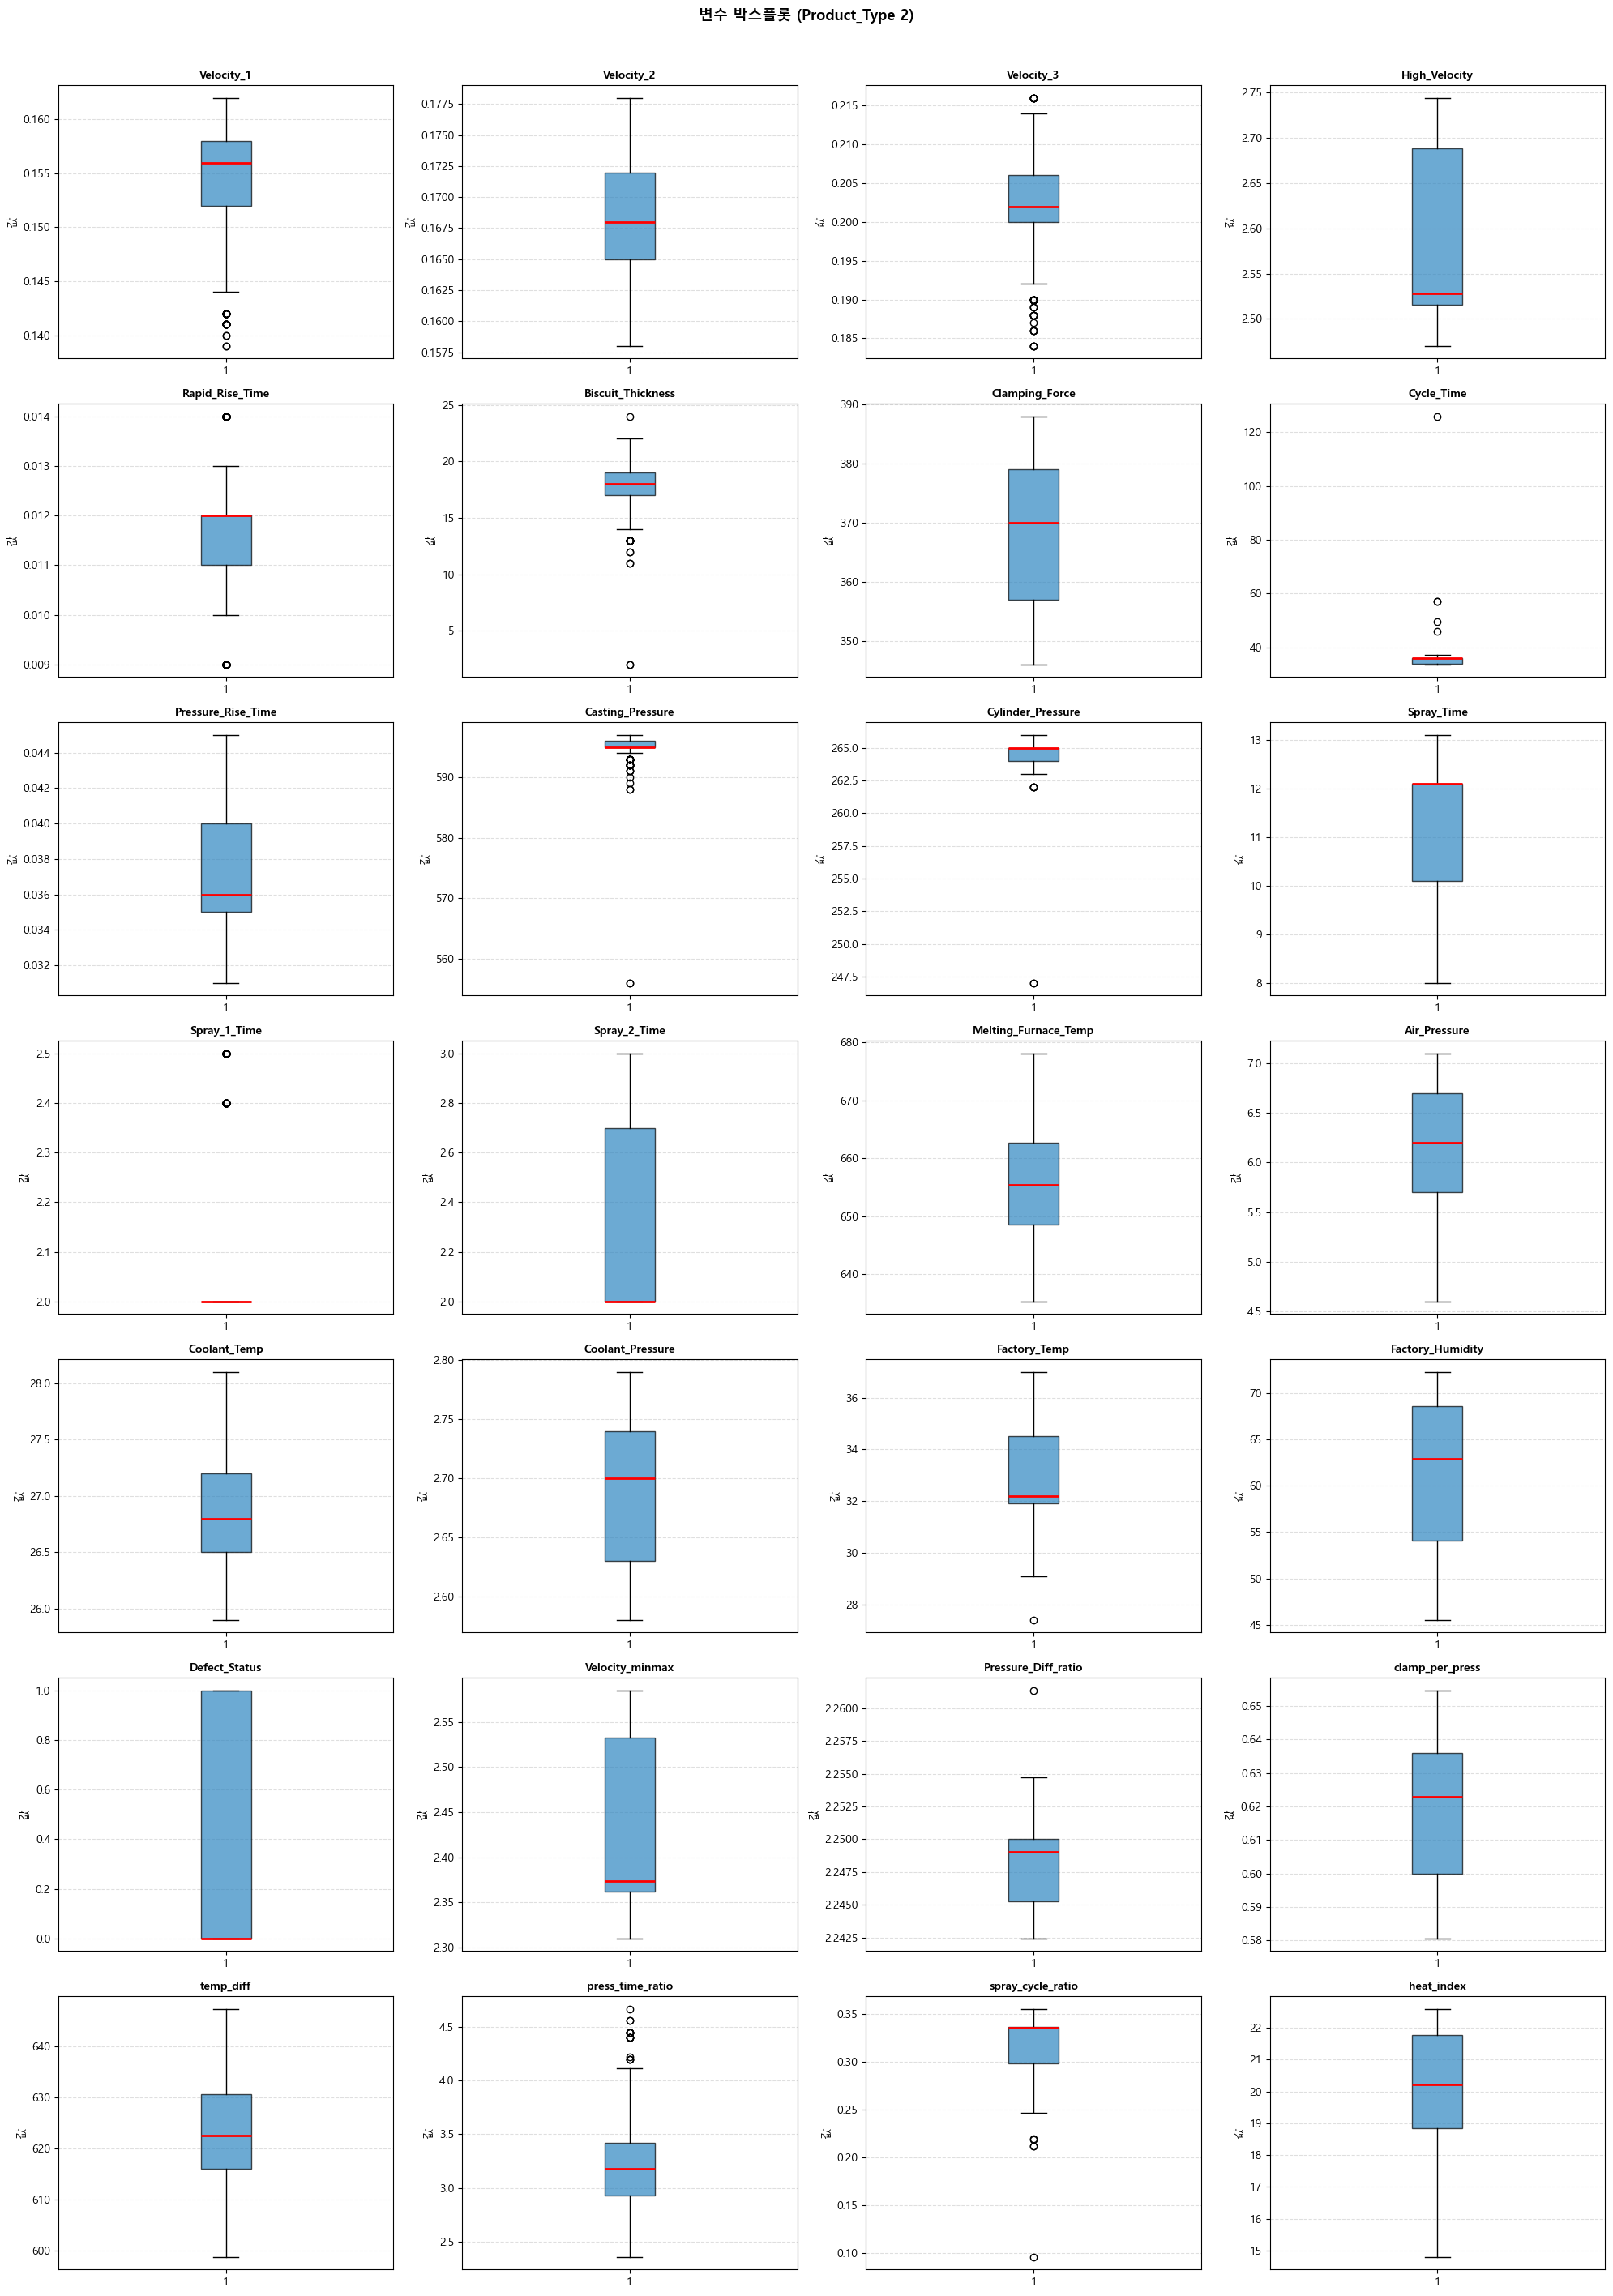

In [12]:
# 변수 박스플롯
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(type2_df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#2E86C1', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('값')
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('변수 박스플롯 (Product_Type 2)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

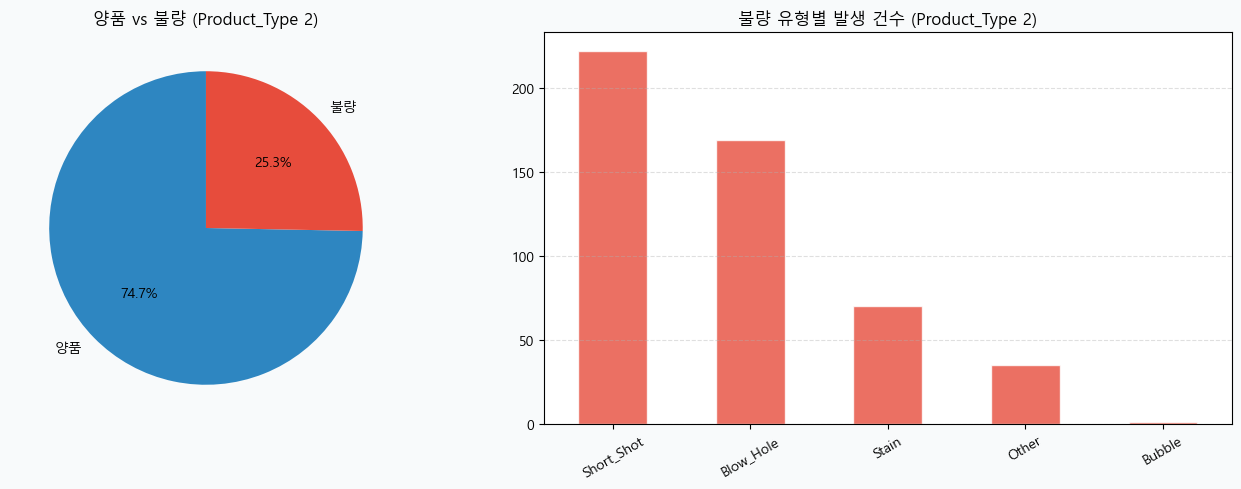

In [13]:
# 불량 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#F8FAFB')

# 파이 차트
sizes = type2_df['Defect_Status'].value_counts().sort_index()
axes[0].pie(sizes, labels=['양품', '불량'], autopct='%1.1f%%',
            colors=['#2E86C1', '#E74C3C'], startangle=90)
axes[0].set_title(f'양품 vs 불량 (Product_Type 2)')

# 불량 유형 바 차트
defect_counts = type2_df[type2_df['Defect_Status']==1]['Defect_Type'].value_counts()
defect_counts.plot(kind='bar', ax=axes[1], color='#E74C3C', alpha=0.8, edgecolor='white')
axes[1].set_title('불량 유형별 발생 건수 (Product_Type 2)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [14]:
defect_counts = type2_df['Defect_Type'].value_counts()
defect_counts

Defect_Type
Normal        1467
Short_Shot     222
Blow_Hole      169
Stain           70
Other           35
Bubble           1
Name: count, dtype: int64

In [15]:
from scipy.stats import spearmanr

exclude_cols = ['Defect_Status', 'Defect_Type', 'id', 'Product_Type', 'Shot',
                'Velocity_minmax', 'Velocity_diff_1_2', 'Velocity_diff_2_3', 'Velocity_diff_3_high','vel_accel', 'vel_ratio']

results = []
for col in type2_df.columns:
    if col in exclude_cols:
        continue
    if type2_df[col].dtype not in ['int64', 'float64']:
        continue
    clean = type2_df[[col, 'Defect_Status']].dropna()
    corr, p = spearmanr(clean[col], clean['Defect_Status'])
    results.append({
        '변수': col,
        '스피어만 상관계수': round(corr, 4),
        'p-value': round(p, 4),
        '절댓값': round(abs(corr), 4)
    })

spearman_df = pd.DataFrame(results).sort_values('절댓값', ascending=False)
spearman_df.insert(0, 'rank', range(0, len(spearman_df)))
spearman_df = spearman_df.set_index('rank')
display(spearman_df)

,변수,스피어만 상관계수,p-value,절댓값
rank,,,,
0,High_Velocity,-0.2333,0.0000,0.2333
1,Factory_Temp,-0.1996,0.0000,0.1996
2,Spray_2_Time,-0.1881,0.0000,0.1881
3,spray_cycle_ratio,0.1799,0.0000,0.1799
4,Clamping_Force,0.1657,0.0000,0.1657
5,Spray_Time,0.1654,0.0000,0.1654
6,clamp_per_press,0.1647,0.0000,0.1647
7,Coolant_Pressure,0.1582,0.0000,0.1582
8,Pressure_Rise_Time,-0.1454,0.0000,0.1454


In [16]:
high_corr_vars = ['Casting_Pressure', 'Cylinder_Pressure', 'Pressure_Diff_ratio']
print("[ 다중공선성 의심 변수 상관관계 ]")
display(type2_df[high_corr_vars].corr().round(3))
print()
print("※ 상관계수 0.99 → 셋 중 Pressure_Diff(파생변수)만 유지 권장")
print("  Pressure_Diff = Casting_Pressure - Cylinder_Pressure")
print("  → 두 압력의 차이가 실질적인 정보를 담고 있음")

[ 다중공선성 의심 변수 상관관계 ]


,Casting_Pressure,Cylinder_Pressure,Pressure_Diff_ratio
Casting_Pressure,1.000,0.881,0.054
Cylinder_Pressure,0.881,1.000,-0.424
Pressure_Diff_ratio,0.054,-0.424,1.000



※ 상관계수 0.99 → 셋 중 Pressure_Diff(파생변수)만 유지 권장
  Pressure_Diff = Casting_Pressure - Cylinder_Pressure
  → 두 압력의 차이가 실질적인 정보를 담고 있음


In [17]:
top10 = spearman_df.head(10).copy()

print("🏆 TOP 10 변수 (상관계수 기준)")
print("-" * 50)

for idx, row in top10.iterrows():   # idx가 rank 인덱스
    direction = "▼ 불량 감소" if row['스피어만 상관계수'] < 0 else "▲ 불량 증가"
    print(f"  #{int(idx):2d}  {row['변수']:<25}  {row['스피어만 상관계수']:+.4f}  {direction}")

🏆 TOP 10 변수 (상관계수 기준)
--------------------------------------------------
  # 0  High_Velocity              -0.2333  ▼ 불량 감소
  # 1  Factory_Temp               -0.1996  ▼ 불량 감소
  # 2  Spray_2_Time               -0.1881  ▼ 불량 감소
  # 3  spray_cycle_ratio          +0.1799  ▲ 불량 증가
  # 4  Clamping_Force             +0.1657  ▲ 불량 증가
  # 5  Spray_Time                 +0.1654  ▲ 불량 증가
  # 6  clamp_per_press            +0.1647  ▲ 불량 증가
  # 7  Coolant_Pressure           +0.1582  ▲ 불량 증가
  # 8  Pressure_Rise_Time         -0.1454  ▼ 불량 감소
  # 9  Cylinder_Pressure          +0.1288  ▲ 불량 증가


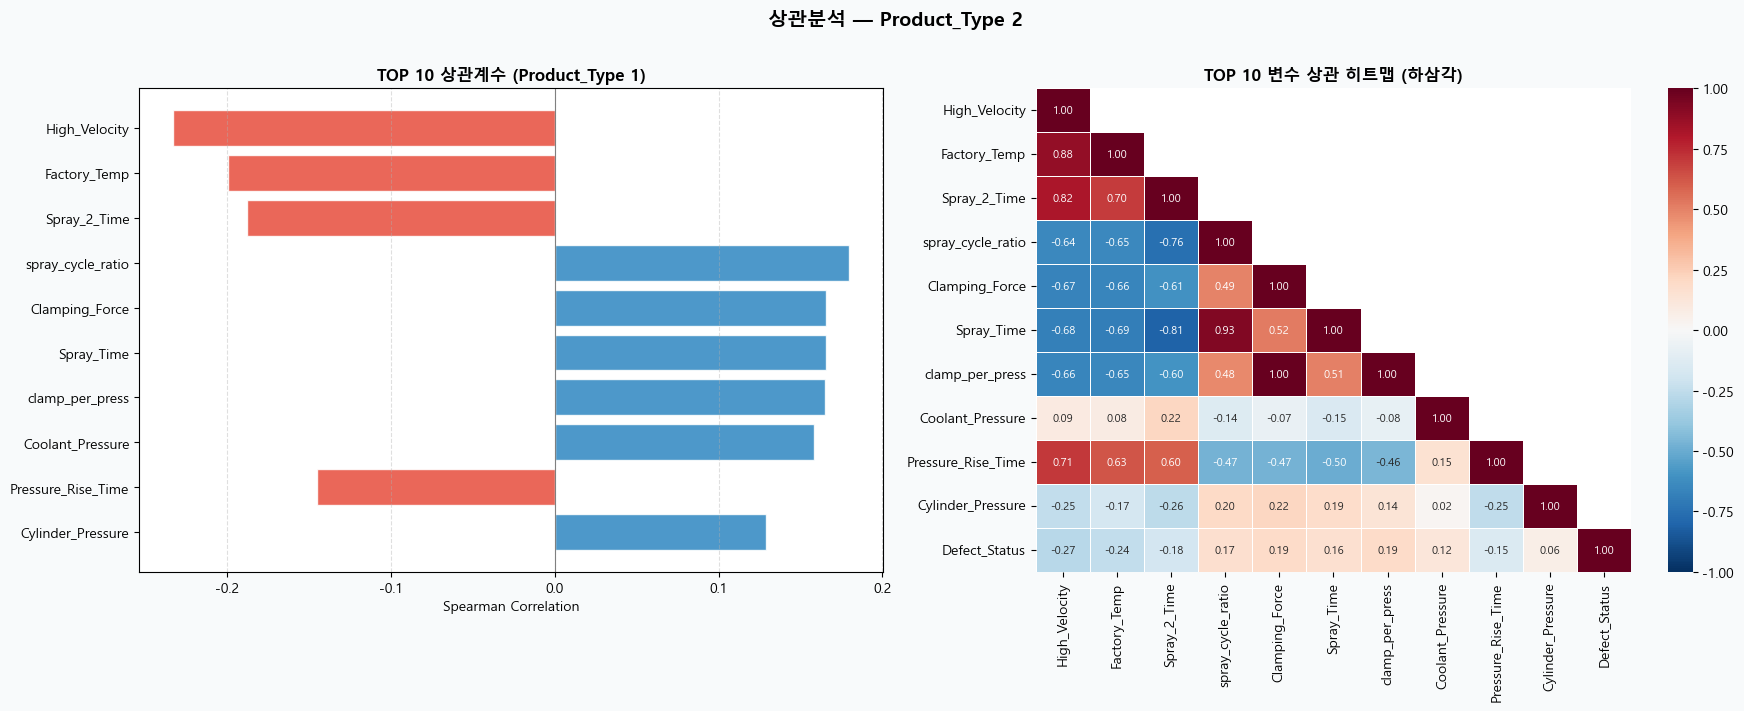

In [18]:
import numpy as np
# 상관계수 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#F8FAFB')

# 바 차트
colors = ['#E74C3C' if v < 0 else '#2E86C1' for v in top10['스피어만 상관계수']]
axes[0].barh(top10['변수'][::-1], top10['스피어만 상관계수'][::-1],
             color=colors[::-1], alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='gray', lw=0.8)
axes[0].set_title('TOP 10 상관계수 (Product_Type 1)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Spearman Correlation')
axes[0].grid(axis='x', linestyle='--', alpha=0.4)

# 히트맵
top10_vars = top10['변수'].tolist()
corr_matrix = type2_df[top10_vars + ['Defect_Status']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, ax=axes[1], annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot_kws={'size': 8}, linewidths=0.5)
axes[1].set_title('TOP 10 변수 상관 히트맵 (하삼각)', fontsize=12, fontweight='bold')

plt.suptitle('상관분석 — Product_Type 2', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [19]:
from scipy import stats

# 원본 변수 + 신규 파생변수 포함
target_vars = [
    'Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity',
    'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time',
    'Pressure_Rise_Time', 'Casting_Pressure', 'Cylinder_Pressure',
    'Spray_Time', 'Spray_1_Time', 'Spray_2_Time',
    'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp', 'Coolant_Pressure',
    'Factory_Temp', 'Factory_Humidity',
    'Pressure_Diff_ratio',
    # 신규 파생변수
    'clamp_per_press', 'temp_diff',
    'press_time_ratio', 'spray_cycle_ratio', 'heat_index'    
]

results = []
for col in target_vars:
    valid = type2_df[[col, 'Defect_Status']].dropna()
    stat, p = stats.shapiro(valid[col])
    results.append({
        '변수': col,
        'W통계량': round(stat, 4),
        'p-value': round(p, 4),
        '정규성': '✅' if p > 0.05 else '❌'
    })

display(pd.DataFrame(results))

,변수,W통계량,p-value,정규성
0,Velocity_1,0.9261,0.0,❌
1,Velocity_2,0.9685,0.0,❌
2,Velocity_3,0.9860,0.0,❌
3,High_Velocity,0.7260,0.0,❌
4,Rapid_Rise_Time,0.7695,0.0,❌
5,Biscuit_Thickness,0.9071,0.0,❌
6,Clamping_Force,0.8975,0.0,❌
7,Cycle_Time,0.2149,0.0,❌
8,Pressure_Rise_Time,0.8899,0.0,❌
9,Casting_Pressure,0.3310,0.0,❌


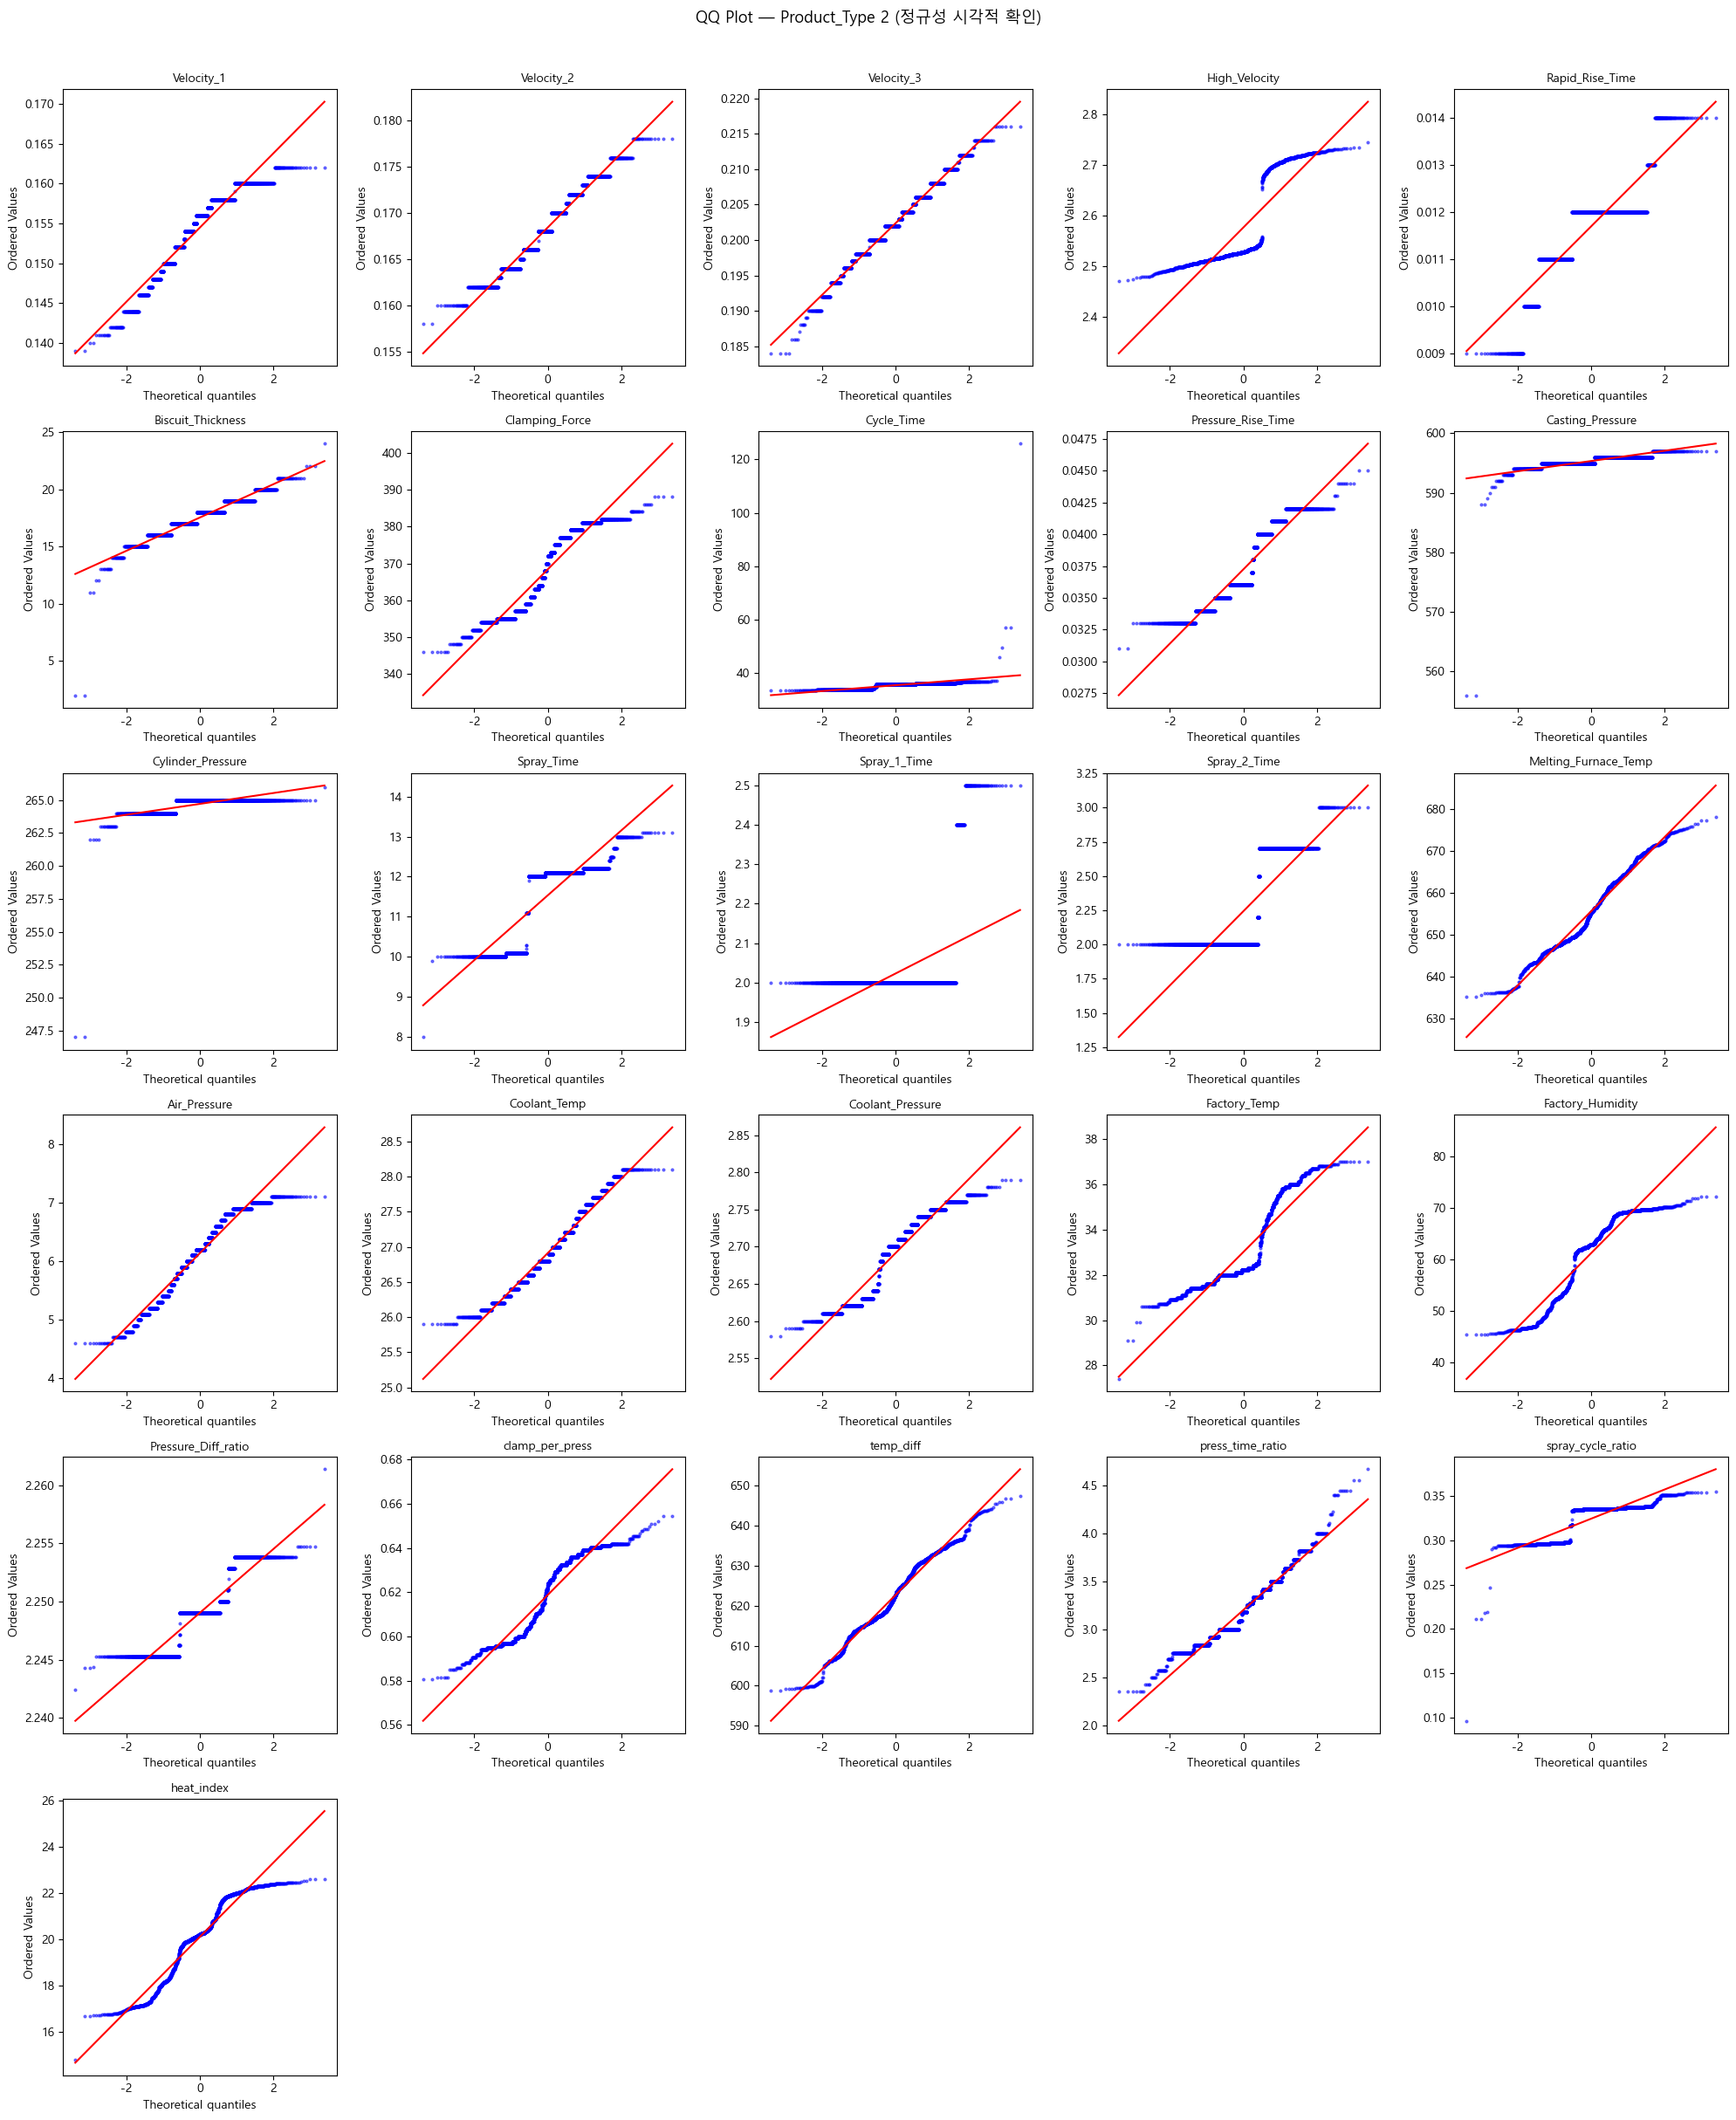

In [20]:
#---------------------
# 1-2. QQ Plot
#---------------------

import scipy.stats as stats
import matplotlib.pyplot as plt
import math

n_vars = len(target_vars)
n_cols = 5
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(target_vars):
    stats.probplot(type2_df[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].get_lines()[0].set(markersize=2, alpha=0.5)

# 남는 빈 서브플롯 숨기기
for j in range(n_vars, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('QQ Plot — Product_Type 2 (정규성 시각적 확인)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [21]:
#---------------------
# 2. Mann-Whitney U 검정
#---------------------

from scipy.stats import mannwhitneyu

defect   = type2_df[type2_df['Defect_Status'] == 1]
normal   = type2_df[type2_df['Defect_Status'] == 0]

results = []
for col in target_vars:
    stat, p = mannwhitneyu(
        defect[col].dropna(),
        normal[col].dropna(),
        alternative='two-sided'
    )
    results.append({
        '변수': col,
        'U통계량': round(stat, 1),
        'p-value': round(p, 4),
        '유의성': '✅' if p < 0.05 else '❌'
    })

result_df = pd.DataFrame(results).sort_values('p-value')
#print(result_df.to_string(index=False))
display(pd.DataFrame(results))

,변수,U통계량,p-value,유의성
0,Velocity_1,348590.5,0.1409,❌
1,Velocity_2,400620.0,0.0009,✅
2,Velocity_3,320930.5,0.0001,✅
3,High_Velocity,251630.5,0.0000,✅
4,Rapid_Rise_Time,359371.0,0.5802,❌
5,Biscuit_Thickness,387412.0,0.0321,✅
6,Clamping_Force,444534.0,0.0000,✅
7,Cycle_Time,421914.0,0.0000,✅
8,Pressure_Rise_Time,294948.0,0.0000,✅
9,Casting_Pressure,410560.0,0.0000,✅


In [22]:
#---------------------
# 3. 효과크기 계산 (Rank-Biserial Correlation)
#---------------------

from scipy.stats import mannwhitneyu
import numpy as np

def rank_biserial(u_stat, n1, n2):
    return (2 * u_stat) / (n1 * n2) - 1

defect = type2_df[type2_df['Defect_Status'] == 1]
normal = type2_df[type2_df['Defect_Status'] == 0]
n1, n2 = len(defect), len(normal)

results = []
for col in target_vars:
    stat, p = mannwhitneyu(defect[col].dropna(), normal[col].dropna(), alternative='two-sided')
    r = abs(rank_biserial(stat, n1, n2))
    results.append({
        '변수': col,
        'p-value': round(p, 4),
        '효과크기(r)': round(r, 4),
        '해석': '대' if r >= 0.5 else '중' if r >= 0.3 else '소'
    })

result_df = pd.DataFrame(results).sort_values('효과크기(r)', ascending=False)
display(pd.DataFrame(results))

,변수,p-value,효과크기(r),해석
0,Velocity_1,0.1409,0.0438,소
1,Velocity_2,0.0009,0.0989,소
2,Velocity_3,0.0001,0.1197,소
3,High_Velocity,0.0000,0.3097,중
4,Rapid_Rise_Time,0.5802,0.0142,소
5,Biscuit_Thickness,0.0321,0.0627,소
6,Clamping_Force,0.0000,0.2194,소
7,Cycle_Time,0.0000,0.1574,소
8,Pressure_Rise_Time,0.0000,0.1909,소
9,Casting_Pressure,0.0000,0.1262,소


In [23]:
#-------------------------------------------
# 4. Kruskal-Wallis H 검정 (Defect_Type별 차이
#-------------------------------------------

from scipy.stats import kruskal

defect_types = ['Blow_Hole', 'Short_Shot', 'Stain', 'Bubble', 'Normal']

results = []
for col in target_vars:
    groups = [type2_df[type2_df['Defect_Type'] == dt][col].dropna() for dt in defect_types]
    stat, p = kruskal(*groups)
    results.append({
        '변수': col,
        'H통계량': round(stat, 2),
        'p-value': round(p, 4),
        '유의성': '✅' if p < 0.05 else '❌'
    })

result_df = pd.DataFrame(results).sort_values('p-value')
display(pd.DataFrame(results))

,변수,H통계량,p-value,유의성
0,Velocity_1,4.08,0.3954,❌
1,Velocity_2,13.83,0.0079,✅
2,Velocity_3,21.14,0.0003,✅
3,High_Velocity,158.84,0.0000,✅
4,Rapid_Rise_Time,6.57,0.1603,❌
5,Biscuit_Thickness,13.48,0.0092,✅
6,Clamping_Force,86.60,0.0000,✅
7,Cycle_Time,54.23,0.0000,✅
8,Pressure_Rise_Time,68.91,0.0000,✅
9,Casting_Pressure,37.34,0.0000,✅


In [24]:
#---------------------
# 5. 효과크기 계산 (Epsilon-squared)
#---------------------

from scipy.stats import kruskal

defect_types = ['Blow_Hole', 'Short_Shot', 'Stain', 'Bubble', 'Normal', 'Other']
n_total = len(type2_df)

target_vars_stat = [col for col in target_vars if col not in ['Defect_Status', 'Defect_Type']]

results = []
for col in target_vars_stat:
    groups = [type2_df[type2_df['Defect_Type'] == dt][col].dropna() for dt in defect_types]
    stat, p = kruskal(*groups)
    
    eps_sq = stat / (n_total - 1)
    
    results.append({
        '변수': col,
        'H통계량': round(stat, 2),
        'p-value': round(p, 4),
        'ε²': round(eps_sq, 4),
        '해석': '대' if eps_sq >= 0.14 else '중' if eps_sq >= 0.06 else '소'
    })

result_df = pd.DataFrame(results).sort_values('ε²', ascending=False)
display(result_df)

,변수,H통계량,p-value,ε²,해석
3,High_Velocity,208.05,0.0000,0.1060,중
18,Factory_Temp,196.66,0.0000,0.1002,중
13,Spray_2_Time,185.23,0.0000,0.0944,중
19,Factory_Humidity,139.95,0.0000,0.0713,중
17,Coolant_Pressure,137.84,0.0000,0.0702,중
25,heat_index,131.33,0.0000,0.0669,중
24,spray_cycle_ratio,128.18,0.0000,0.0653,중
11,Spray_Time,120.41,0.0000,0.0613,중
6,Clamping_Force,119.16,0.0000,0.0607,중
21,clamp_per_press,117.09,0.0000,0.0596,소


In [25]:
#---------------------
# 6. Dunn's post-hoc test (Defect_Type별 세부 차이
#---------------------
from IPython.display import display
import scikit_posthocs as sp

def duntest(df, vars_list, defect_types=None):
    if defect_types is None:
        defect_types = ['Blow_Hole', 'Short_Shot', 'Stain', 'Bubble', 'Normal']
    
    final_vars_stat = [col for col in vars_list if col not in ['Defect_Status', 'Defect_Type']]
    results = {}  # ← 추가

    for col in final_vars_stat:
        print(f'\n--- {col} ---')
        dunn = sp.posthoc_dunn(
            df[df['Defect_Type'].isin(defect_types)],
            val_col=col,
            group_col='Defect_Type',
            p_adjust='bonferroni'
        )
        display(dunn.round(4))
        results[col] = dunn  # ← 추가

    return results  # ← 추가

# 호출 — 결과를 변수에 저장
dunn_results = duntest(type2_df, final_vars)


--- Velocity_1 ---


,Blow_Hole,Bubble,Normal,Short_Shot,Stain
Blow_Hole,1.0,1.0,1.0,1.0,1.0
Bubble,1.0,1.0,1.0,1.0,1.0
Normal,1.0,1.0,1.0,1.0,1.0
Short_Shot,1.0,1.0,1.0,1.0,1.0
Stain,1.0,1.0,1.0,1.0,1.0



--- Velocity_2 ---


,Blow_Hole,Bubble,Normal,Short_Shot,Stain
Blow_Hole,1.0000,1.0,0.2139,1.0000,1.0000
Bubble,1.0000,1.0,1.0000,1.0000,1.0000
Normal,0.2139,1.0,1.0000,0.2335,0.2063
Short_Shot,1.0000,1.0,0.2335,1.0000,1.0000
Stain,1.0000,1.0,0.2063,1.0000,1.0000



--- Velocity_3 ---


...

,Blow_Hole,Bubble,Normal,Short_Shot,Stain
Blow_Hole,1.0000,1.0,0.0003,1.0000,1.0000
Bubble,1.0000,1.0,1.0000,1.0000,1.0000
Normal,0.0003,1.0,1.0000,0.0037,0.0158
Short_Shot,1.0000,1.0,0.0037,1.0000,1.0000
Stain,1.0000,1.0,0.0158,1.0000,1.0000



--- spray_cycle_ratio ---


,Blow_Hole,Bubble,Normal,Short_Shot,Stain
Blow_Hole,1.0000,0.6553,0.0001,1.0000,0.0004
Bubble,0.6553,1.0000,1.0000,0.5304,0.1596
Normal,0.0001,1.0000,1.0000,0.0000,0.0000
Short_Shot,1.0000,0.5304,0.0000,1.0000,0.0037
Stain,0.0004,0.1596,0.0000,0.0037,1.0000



--- heat_index ---


,Blow_Hole,Bubble,Normal,Short_Shot,Stain
Blow_Hole,1.0000,0.5330,0.0001,1.0000,0.0313
Bubble,0.5330,1.0000,1.0000,0.3653,1.0000
Normal,0.0001,1.0000,1.0000,0.0000,1.0000
Short_Shot,1.0000,0.3653,0.0000,1.0000,0.0003
Stain,0.0313,1.0000,1.0000,0.0003,1.0000


In [26]:
#---------------------
# 6-2. 유의 쌍 요약 (p < 0.05)
#---------------------
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 유의 변수 필터링
sig_vars = []
for col, dunn in dunn_results.items():
    arr = dunn.values.copy()
    np.fill_diagonal(arr, 1.0)
    if (arr < 0.05).any():
        sig_vars.append(col)

n = len(sig_vars)
if n == 0:
    print("유의한 변수가 없습니다.")
else:
    n_cols = 3
    n_rows = -(-n // n_cols)
    
summary_rows = []

for col in sig_vars:
    dunn = dunn_results[col]
    labels = list(dunn.columns)
    for r_idx, r in enumerate(labels):
        for c_idx, c in enumerate(labels):
            if c_idx <= r_idx:
                continue
            p = dunn.loc[r, c]
            if p < 0.05:
                summary_rows.append({
                    '변수': col,
                    '집단 A': r,
                    '집단 B': c,
                    'p-value (Bonferroni)': round(p, 4),
                    '유의수준': '***' if p < 0.001 else '**' if p < 0.01 else '*'
                })

summary_df = pd.DataFrame(summary_rows).sort_values(['변수', 'p-value (Bonferroni)'])
print(f"유의한 쌍 총 {len(summary_df)}개")
display(summary_df.reset_index(drop=True))

유의한 쌍 총 74개


,변수,집단 A,집단 B,p-value (Bonferroni),유의수준
0,Air_Pressure,Blow_Hole,Short_Shot,0.0098,**
1,Air_Pressure,Blow_Hole,Normal,0.0418,*
2,Biscuit_Thickness,Normal,Short_Shot,0.0363,*
3,Casting_Pressure,Normal,Stain,0.0000,***
4,Casting_Pressure,Blow_Hole,Normal,0.0058,**
...,...,...,...,...,...
69,spray_cycle_ratio,Short_Shot,Stain,0.0037,**
70,temp_diff,Blow_Hole,Stain,0.0000,***
71,temp_diff,Normal,Stain,0.0000,***
72,temp_diff,Short_Shot,Stain,0.0133,*


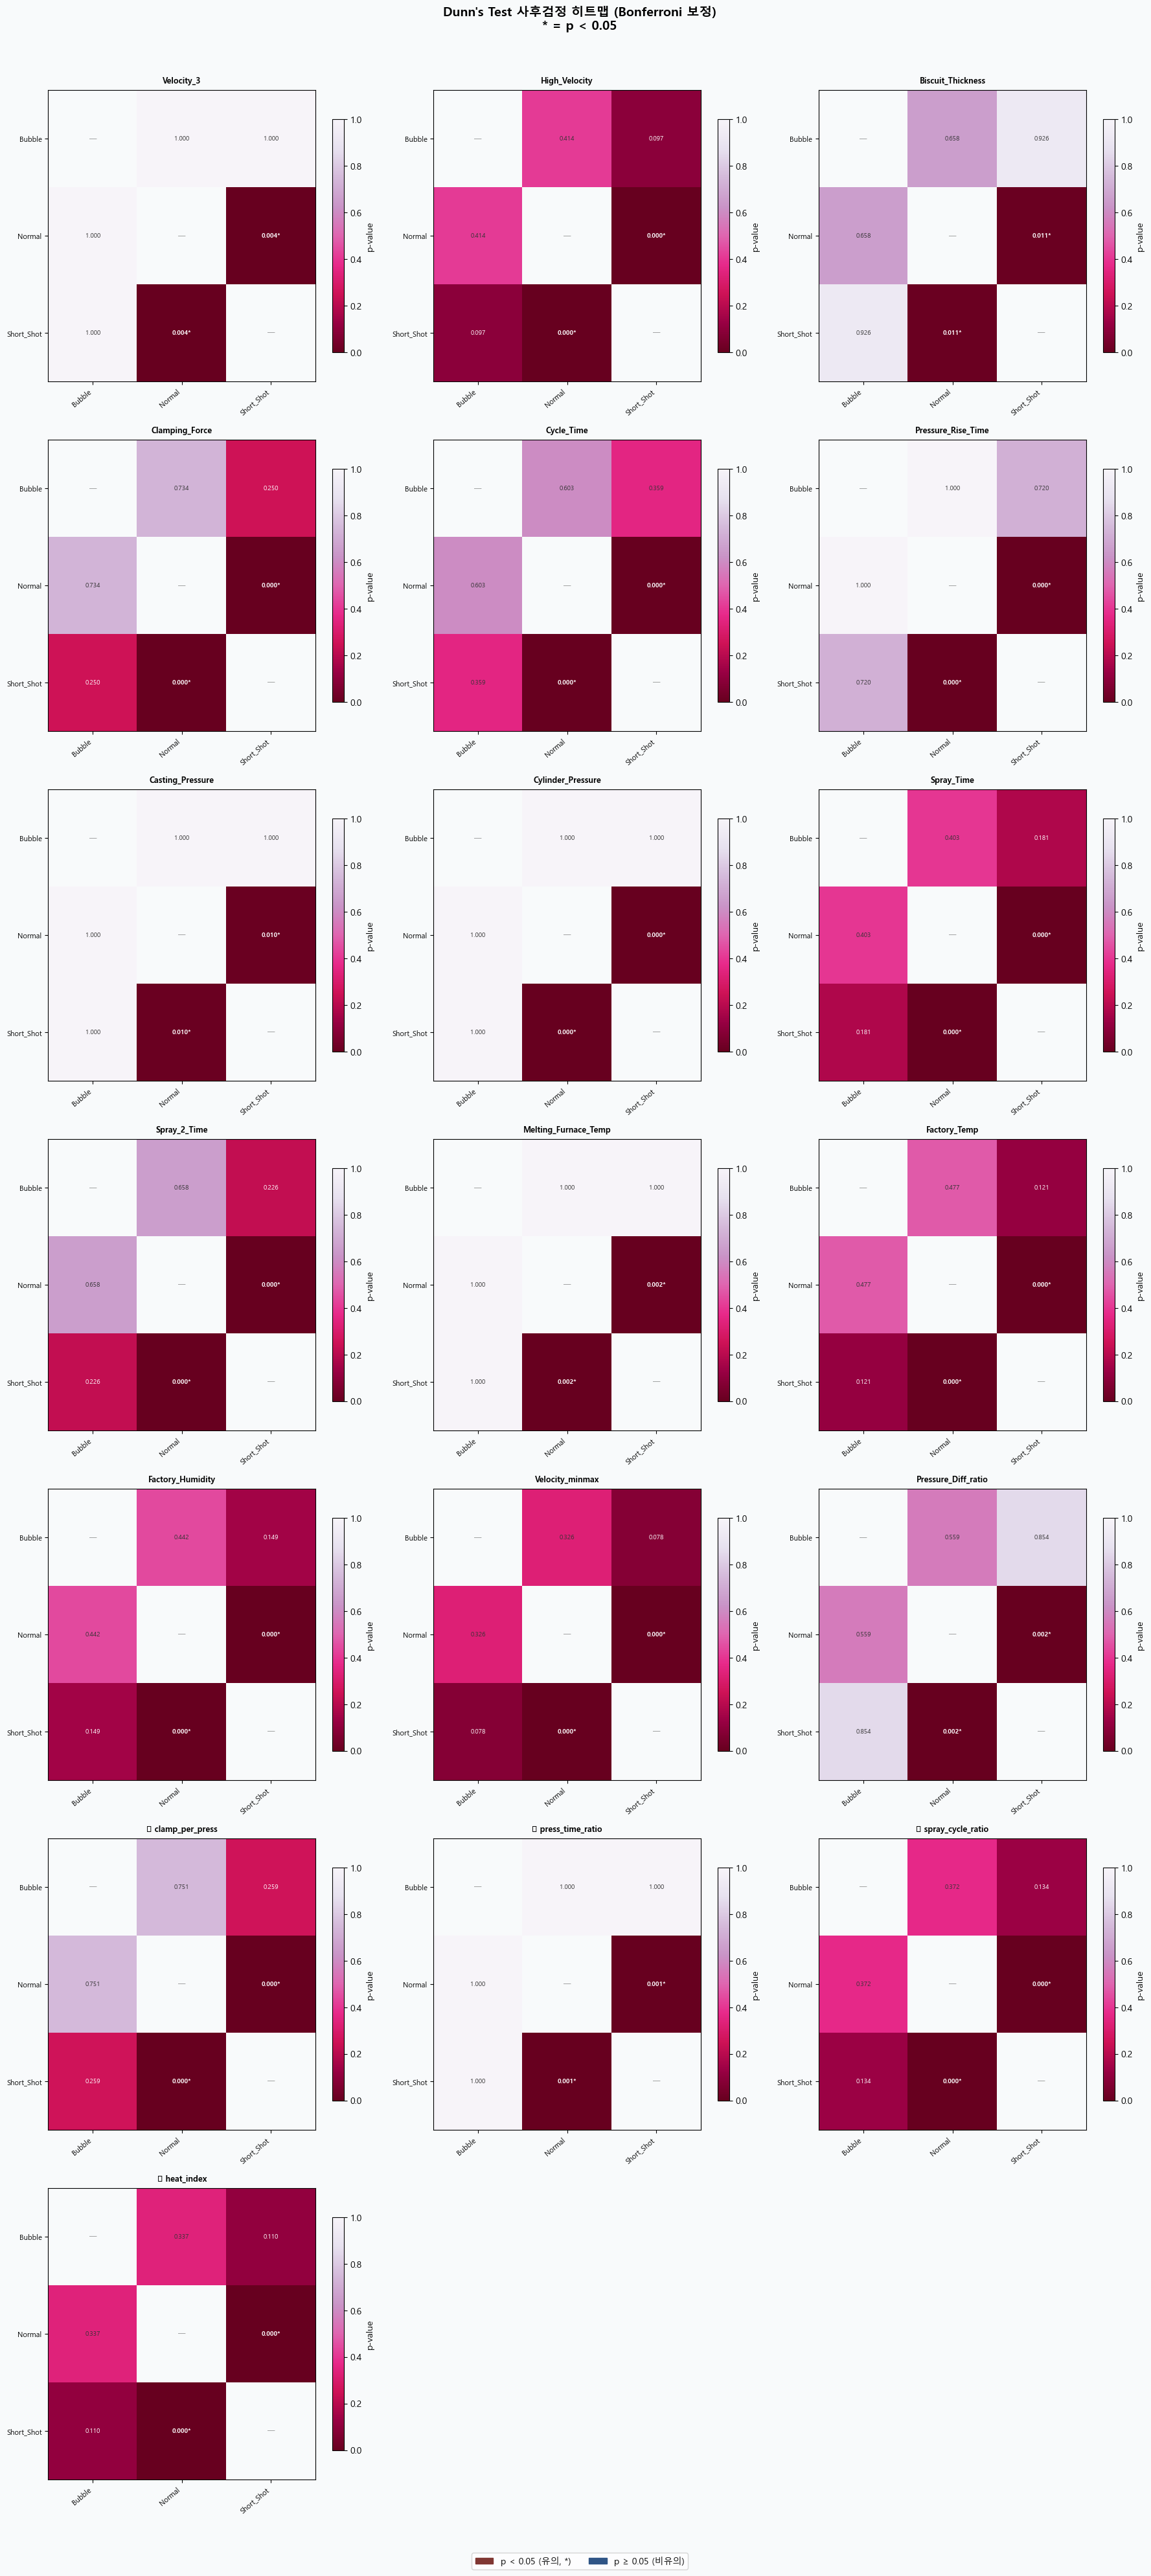

In [56]:
#---------------------
# 6-1. Dunn's Test 히트맵
#---------------------
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 유의 변수 필터링
sig_vars = []
for col, dunn in dunn_results.items():
    arr = dunn.values.copy()
    np.fill_diagonal(arr, 1.0)
    if (arr < 0.05).any():
        sig_vars.append(col)

n = len(sig_vars)
if n == 0:
    print("유의한 변수가 없습니다.")
else:
    n_cols = 3
    n_rows = -(-n // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, squeeze=False,  # ← 수정
                              figsize=(n_cols * 6, n_rows * 5.5),
                              facecolor='#F8FAFB')
    axes = axes.flatten()  # ← np.array() 불필요

    new_derived = ['clamp_per_press', 'temp_diff', 'press_time_ratio',
                   'spray_cycle_ratio', 'heat_index']  # ← 루프 밖으로

    for i, col in enumerate(sig_vars):
        ax = axes[i]
        dunn = dunn_results[col]
        labels = list(dunn.columns)
        mat = dunn.values.copy()
        np.fill_diagonal(mat, np.nan)

        im = ax.imshow(mat, cmap='PuRd_r', vmin=0, vmax=1, aspect='auto')

        for r in range(len(labels)):
            for c in range(len(labels)):
                if r == c:
                    ax.text(c, r, '—', ha='center', va='center',
                            fontsize=8, color='#888888')
                else:
                    p = mat[r, c]
                    sig_mark = '*' if p < 0.05 else ''
                    color = 'white' if p < 0.3 else '#333333'
                    ax.text(c, r, f'{p:.3f}{sig_mark}',
                            ha='center', va='center',
                            fontsize=7, fontweight='bold' if p < 0.05 else 'normal',
                            color=color)

        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_title(f'{"🆕 " if col in new_derived else ""}{col}',
                     fontsize=9, fontweight='bold', pad=8)
        ax.set_facecolor('#F8FAFB')
        plt.colorbar(im, ax=ax, shrink=0.8, label='p-value')

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    sig_patch = mpatches.Patch(color='#803733', label='p < 0.05 (유의, *)')
    ns_patch  = mpatches.Patch(color='#305586', label='p ≥ 0.05 (비유의)')
    fig.legend(handles=[sig_patch, ns_patch],
               loc='lower center', ncol=2, fontsize=10,
               bbox_to_anchor=(0.5, -0.02))

    fig.suptitle("Dunn's Test 사후검정 히트맵 (Bonferroni 보정)\n* = p < 0.05",
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

In [28]:
# Normal 포함된 쌍만 필터
normal_summary = summary_df[
    (summary_df['집단 A'] == 'Normal') | (summary_df['집단 B'] == 'Normal')
]

var_count = (normal_summary.groupby('변수')
                            .size()
                            .reset_index(name='유의_쌍_수')
                            .sort_values('유의_쌍_수', ascending=False))

top_bottom = pd.concat([var_count.head(10), var_count.tail(10)]).drop_duplicates()
display(top_bottom)

,변수,유의_쌍_수
0,Biscuit_Thickness,1
1,Casting_Pressure,1
2,Clamping_Force,1
3,Cycle_Time,1
4,Cylinder_Pressure,1
5,Factory_Humidity,1
6,Factory_Temp,1
7,High_Velocity,1
8,Melting_Furnace_Temp,1
9,Pressure_Diff_ratio,1


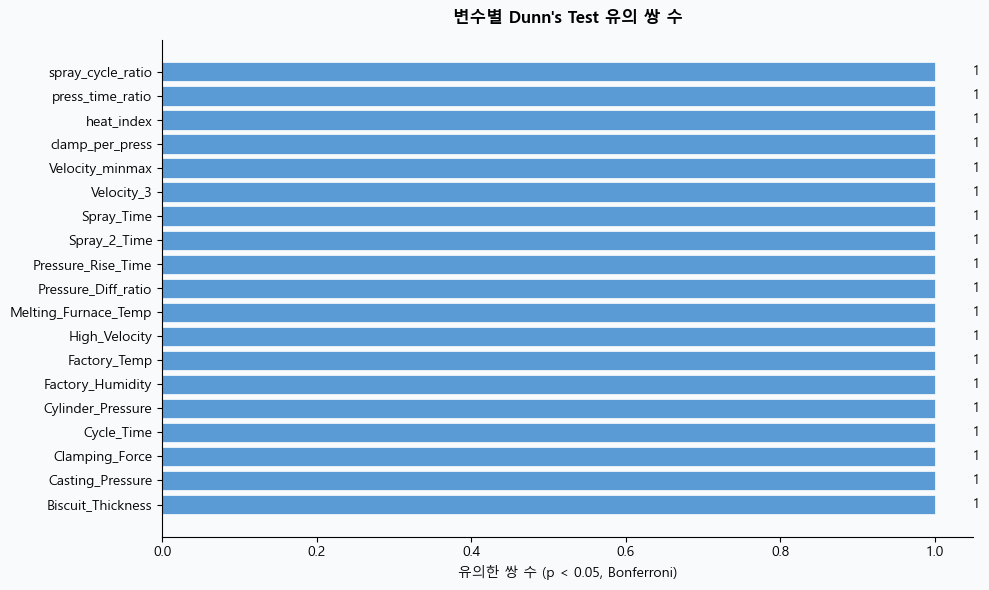

In [30]:
import matplotlib.pyplot as plt

var_count_sorted = var_count.sort_values('유의_쌍_수', ascending=False)  # ← 추가

fig, ax = plt.subplots(figsize=(10, 6), facecolor='#F8FAFB')

bars = ax.barh(var_count_sorted['변수'], var_count_sorted['유의_쌍_수'],
               color='#5B9BD5', edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, var_count_sorted['유의_쌍_수']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('유의한 쌍 수 (p < 0.05, Bonferroni)', fontsize=10)
ax.set_title("변수별 Dunn's Test 유의 쌍 수",
             fontsize=12, fontweight='bold', pad=12)
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('#F8FAFB')

plt.tight_layout()
plt.show()